In [1]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import  GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report




In [2]:

from pathlib import Path

BASE_DIR = Path.cwd().parent   # se estiveres em notebooks/
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

In [3]:
df = pd.read_csv(DATA_DIR / "train.csv")
df.head()
dt = pd.read_csv(DATA_DIR / "test.csv")

In [4]:
features = [
    'ChiefComplaint',
    'age',
    'PulseRate',
    'RespiratoryRate',
    'gender']

target = 'TriageGrade'

df = df[features + [target]]
dt = dt[features + [target]]


In [5]:
X_train = df[features]
y_train = df[target]

X_test = dt[features]
y_test = dt[target]


In [6]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=19,
    random_state=42,
    class_weight='balanced',
)

In [7]:
categorical_features = ['ChiefComplaint', 'gender']
numerical_features = ['age', 'PulseRate', 'RespiratoryRate']

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        )
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])


In [8]:
param_grid = {
    "classifier__max_depth": range(1, 21),
    "classifier__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 13}
Best CV score: 0.7636549369717425


In [9]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.33      0.54      0.41      2058
           2       0.82      0.79      0.80     16191
           3       0.91      0.89      0.90      6864
           4       0.78      0.58      0.67      3548
           5       0.00      0.00      0.00         3

    accuracy                           0.77     28664
   macro avg       0.57      0.56      0.56     28664
weighted avg       0.80      0.77      0.78     28664

Accuracy: 0.7729556237789562


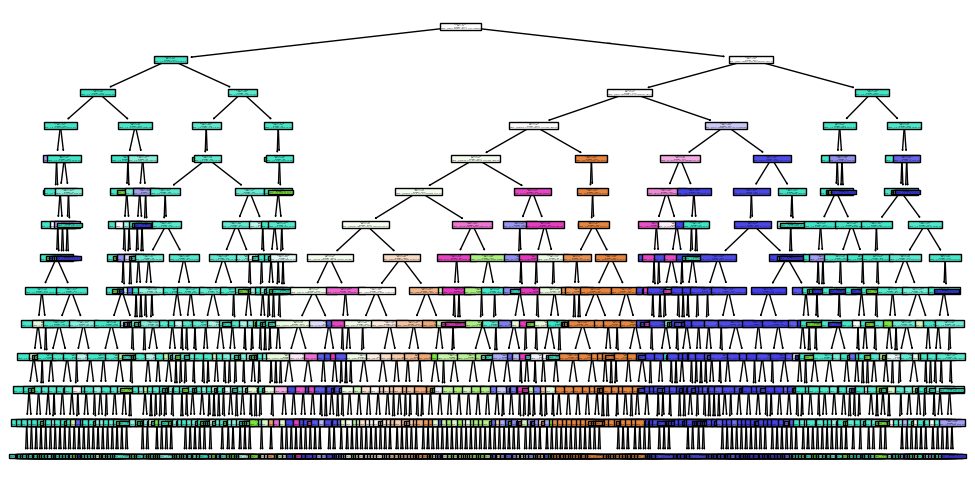

In [10]:
dt_model = best_model.named_steps["classifier"]

plt.figure(figsize=(12,6))
plot_tree(dt_model, filled=True)
plt.show()


In [11]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": best_model,
    "features": features
},"models/decision_tree.joblib")



['models/decision_tree.joblib']